In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

In [2]:
color1 = cm.inferno_r(np.linspace(.4, .8, 30))
color2 = cm.magma_r(np.linspace(.4, .8, 30))
color3 = cm.summer(np.linspace(.4, .8, 30))
ordem = [ 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']


In [3]:
df = pd.read_csv('data-treatment.csv', )

C:\Users\RAFAEL\AppData\Local\Temp\ipykernel_8656\3540814682.py:1: DtypeWarning: Columns (0: km) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data-treatment.csv', )


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1562034 entries, 0 to 1562033
Data columns (total 30 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   data_inversa            1562034 non-null  str   
 1   dia_semana              1562034 non-null  str   
 2   horario                 1562034 non-null  str   
 3   uf                      1562034 non-null  str   
 4   br                      1562034 non-null  int64 
 5   km                      1562034 non-null  object
 6   municipio               1562034 non-null  str   
 7   causa_acidente          1562034 non-null  str   
 8   tipo_acidente           1562034 non-null  str   
 9   classificacao_acidente  1562034 non-null  str   
 10  fase_dia                1562034 non-null  str   
 11  sentido_via             1562034 non-null  str   
 12  condicao_metereologica  1562034 non-null  str   
 13  tipo_pista              1562034 non-null  str   
 14  tracado_via             15620

In [5]:
df['br'] = df['br'].astype(str)
df['km'] = df['km'].astype(str)
df['ano'] = df['ano'].astype(str)

In [6]:
df.describe().round(2)

,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,mes,horas,dia
count,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00,1562034.00
mean,2.16,0.05,0.45,0.16,1.41,0.09,0.61,1.74,6.56,13.05,15.64
std,1.56,0.28,0.98,0.56,1.23,0.38,1.19,0.72,3.49,5.84,8.76
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00
25%,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,4.00,8.00,8.00
50%,2.00,0.00,0.00,0.00,1.00,0.00,0.00,2.00,7.00,14.00,16.00
75%,2.00,0.00,1.00,0.00,2.00,0.00,1.00,2.00,10.00,18.00,23.00
max,248.00,33.00,52.00,222.00,99.00,86.00,239.00,25.00,12.00,23.00,31.00


In [7]:
def plot_bar(a: pd.Series):

    fig, ax = plt.subplots(figsize=(9,3), layout="constrained")

    ax.bar(a.index, a.values, linewidth=0.7, color=color1)

    ax.set(xlim=(0, 8), xticks=np.arange(-1, len(a.index)+1))

    ax.tick_params("x", rotation=45)

    plt.show()

- Quais são os 10 estados com maior número de acidentes registrados?

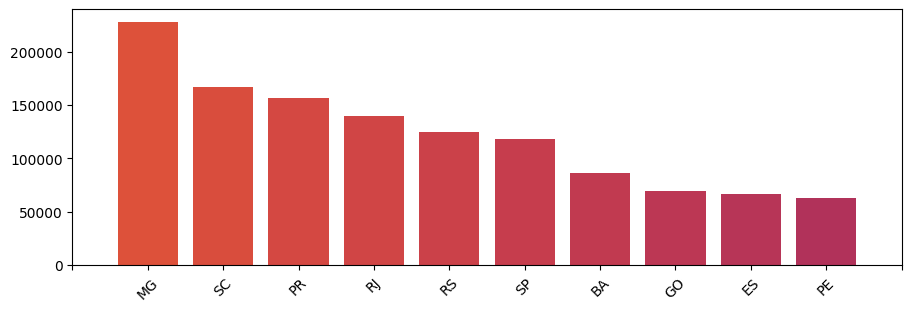

In [8]:
analysis = df.groupby(['uf']).size().sort_values(ascending=False)
plot_bar(analysis[:10])

- Condições metereológicas com mais acidentes

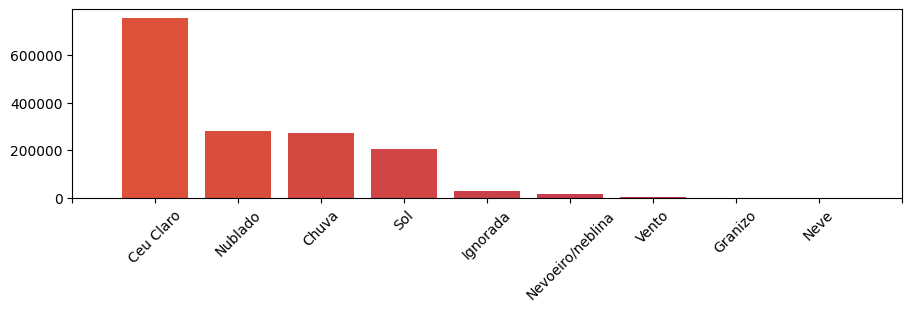

In [9]:
a = df.groupby(['condicao_metereologica']).size().sort_values(ascending=False)
plot_bar(a)

- Horários com mais acidentes

Podemos perceber que no horário comercial é onde concentramos mais acidentes, com um certo pico às 7, horário em que o pessoal está se deslocando para o trabalho e às 18h, com um pico maior, horário que o pessoal está voltando para casa

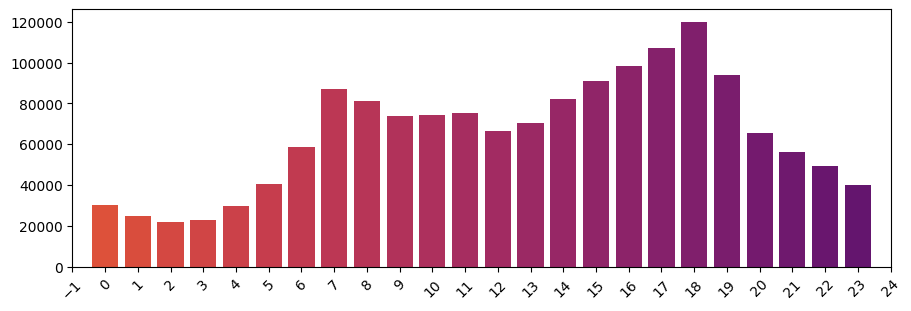

In [10]:
a= df.groupby(['horas'])['horas'].size()

plot_bar(a)

- Quantidade de acidentes ao longo dos anos

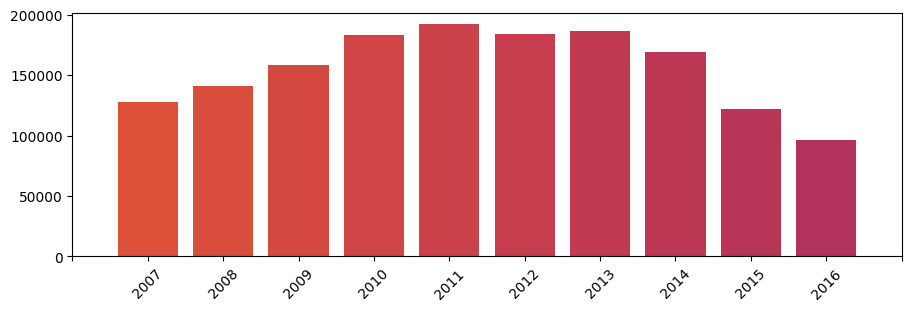

In [11]:
a = df.groupby(['ano'])['ano'].size()

plot_bar(a)

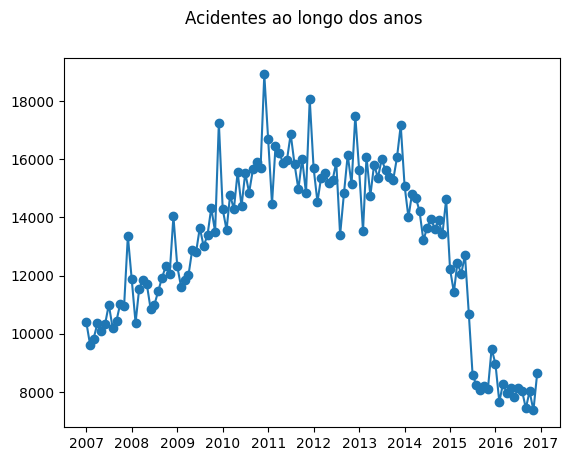

In [12]:
df['ano_mes'] = pd.to_datetime(df['ano_mes'])

a = df.groupby(['ano_mes'])['ano_mes'].size()

fig = plt.figure()

fig.suptitle('Acidentes ao longo dos anos')

ax = fig.add_subplot()

ax.plot(a.index, a.values, '-o')

#ax.set(xticks=np.arange(1, len(lista_series)+1))

plt.show()

- Qual é a distribuição de acidentes por dia da semana?

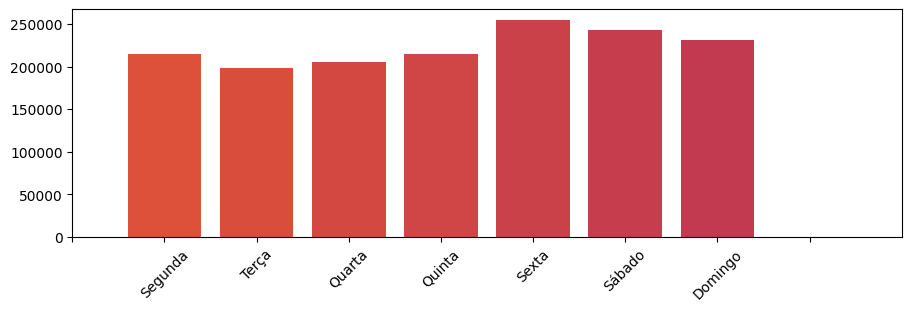

In [13]:
a = df.groupby(by=['dia_semana']).size()
a = a.reindex(ordem)
plot_bar(a)

- Quais meses do ano concentram mais acidentes e mortes?

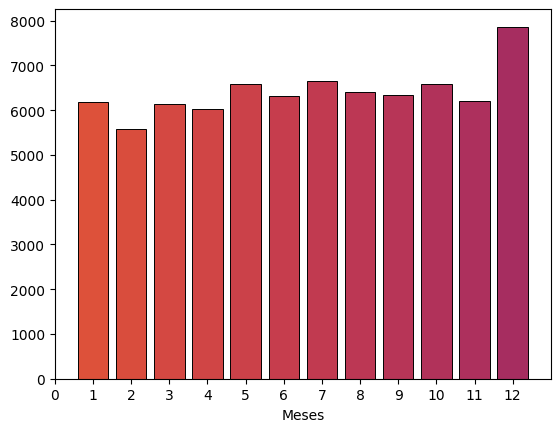

In [14]:
a = df.groupby(['mes'])['mortos'].sum()

fig, ax = plt.subplots()

ax.bar(a.index, a.values, edgecolor='blacK', linewidth=0.7, color=color1)

ax.set(xlim = (0, len(a.index)+1), xticks=np.arange(0, len(a.index)+1))

plt.xlabel('Meses')

plt.show()


- Existe interação entre dia da semana e horário que eleva a gravidade dos acidentes?

Pior que não vemos isso não, todos os dias da semana apresentam o mesmo comportamento com um pico de acidentes entre as 18-19h que aumentam a gravidade, como observado em uma das análises anteriores

In [15]:
n = df.groupby(['dia_semana', 'horas', 'classificacao_acidente']).size()
d = df.groupby(['dia_semana','classificacao_acidente']).size()

p = ((n/d)*100).round(2)
p=p.unstack(level=1)

p.reindex(ordem, level=0)

horas                                0     1     2     3     4     5     6   \
dia_semana classificacao_acidente                                             
Segunda    Com Vítimas Fatais      4.21  3.32  2.91  2.31  2.85  4.69  5.57   
           Com Vítimas Feridas     2.43  1.81  1.43  1.20  1.46  2.53  4.88   
           Ignorado                7.18  5.83  5.67  4.39  4.87  6.70  5.51   
           Sem Vítimas             1.58  1.22  0.96  1.01  1.36  2.17  4.30   
Terça      Com Vítimas Fatais      2.47  1.84  1.92  1.77  2.68  3.70  4.27   
           Com Vítimas Feridas     1.41  1.16  0.94  0.97  1.49  2.30  4.16   
           Ignorado                3.74  4.12  3.09  4.02  3.74  5.71  4.12   
           Sem Vítimas             1.36  1.11  0.98  0.97  1.28  2.06  3.52   
Quarta     Com Vítimas Fatais      2.45  2.09  1.89  1.94  2.41  4.22  4.89   
           Com Vítimas Feridas     1.57  1.21  1.00  1.07  1.42  2.20  4.23   
           Ignorado                5.89  4.13  3.69  4.22  5.01  5.72  4.66   
           Sem Vítimas             1.43  1.19  1.05  1.04  1.30  2.05  3.58   
Quinta     Com Vítimas Fatais      2.88  2.33  2.14  1.96  3.03  4.11  4.62   
           Com Vítimas Feridas     1.77  1.39  1.23  1.15  1.57  2.46  4.31   
           Ignorado                5.20  3.41  4.23  4.72  5.12  6.02  5.20   
           Sem Vítimas             1.56  1.29  1.14  1.07  1.50  2.13  3.58   
Sexta      Com Vítimas Fatais      2.15  2.37  2.04  2.17  2.88  3.97  4.57   
           Com Vítimas Feridas     1.68  1.41  1.21  1.35  1.70  2.25  3.78   
           Ignorado                4.56  5.53  3.66  4.82  6.36  5.91  5.08   
           Sem Vítimas             1.46  1.17  1.05  1.12  1.36  2.06  3.17   
Sábado     Com Vítimas Fatais      3.48  3.24  2.94  3.28  4.44  4.45  4.04   
           Com Vítimas Feridas     2.47  2.14  2.08  2.16  2.86  3.45  3.58   
           Ignorado                3.90  5.17  5.68  5.52  7.06  8.71  6.86   
           Sem Vítimas             2.45  1.97  1.75  1.79  2.45  2.98  3.67   
Domingo    Com Vítimas Fatais      3.70  3.15  3.16  3.87  4.90  4.84  3.63   
           Com Vítimas Feridas     2.77  2.51  2.44  2.75  3.28  3.67  3.37   
           Ignorado                4.34  5.21  4.90  6.81  7.82  8.37  7.12   
           Sem Vítimas             2.26  2.05  1.68  1.93  2.27  2.88  3.01   

horas                                7     8     9   ...    14    15    16  \
dia_semana classificacao_acidente                    ...                     
Segunda    Com Vítimas Fatais      4.48  3.94  3.06  ...  4.29  4.08  4.37   
           Com Vítimas Feridas     7.37  5.67  4.61  ...  5.17  5.37  5.67   
           Ignorado                4.15  3.83  2.87  ...  3.27  3.03  3.99   
           Sem Vítimas             7.49  6.82  5.89  ...  5.70  6.15  6.28   
Terça      Com Vítimas Fatais      4.46  3.54  3.33  ...  4.35  4.77  4.50   
           Com Vítimas Feridas     6.93  5.71  4.72  ...  5.45  5.58  5.75   
           Ignorado                4.86  2.99  3.18  ...  3.18  3.93  3.93   
           Sem Vítimas             6.31  6.43  5.72  ...  5.74  6.33  6.54   
Quarta     Com Vítimas Fatais      4.54  3.68  2.99  ...  4.47  4.66  4.95   
           Com Vítimas Feridas     6.90  5.41  4.63  ...  5.37  5.35  5.80   
           Ignorado                4.31  3.34  2.90  ...  2.73  2.99  3.69   
           Sem Vítimas             6.26  6.24  5.51  ...  5.71  6.25  6.42   
Quinta     Com Vítimas Fatais      4.30  3.65  3.12  ...  4.29  4.25  4.43   
           Com Vítimas Feridas     6.71  5.35  4.45  ...  5.20  5.26  5.73   
           Ignorado                5.12  3.25  3.74  ...  3.66  3.74  3.74   
           Sem Vítimas             6.18  6.21  5.50  ...  5.73  6.20  6.46   
Sexta      Com Vítimas Fatais      3.99  2.75  2.39  ...  3.41  3.96  4.44   
           Com Vítimas Feridas     5.85  4.65  4.03  ...  4.87  5.39  6.31   
           Ignorado                3.41  3.28  2.89  ...  2.63  3.28 

- A redução de acidentes ao longo dos anos é uniforme entre estados ou concentrada em alguns?

Como podemos ver no dataframe abaixo, na maioria dos estados ocorreu sim uma redução do número de acidentes ao longo dos anos, porém, com uma variação diferente. Além disso, podemos perceber um comportamento em muitos dos estados, de uma subida no número de acidentes de 2009 a 2014, e finalmente com uma diminuída até 2016.

São poucos os estados que não seguem esse comportamento, ou até mesmo o a redução final, tais estados como: AP, AC, MS e TO, por exemplo, que passaram por esse pico de acidentes comentados anteriormente, porém ao final não representou uma diminuição em relação ao começo, terminado com uma % acima do valor inicial, em muitos casos bem pequena, sendo a maior delas o TO, com 17% de aumento em relação ao valor inicial

In [16]:
df.groupby(['uf', 'ano']).size().unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
uf,,,,,,,,,,
AC,324,353,365,462,518,503,448,457,468,330
AL,1604,1778,1914,2276,2364,2195,2375,1528,1071,951
AM,173,194,199,239,249,218,234,168,131,166
AP,150,168,161,162,232,241,277,273,218,198
BA,7085,7628,8208,9440,10433,10279,10388,10404,7152,5496
CE,2260,2691,2913,3784,3824,3746,4010,3791,2636,2419
DF,1137,1044,1228,1299,1583,1448,1535,1327,1040,1066
ES,6239,6381,6746,7830,7952,7718,8217,7805,4762,3230
GO,5607,6452,7179,8012,8060,7691,7986,7125,6131,4968


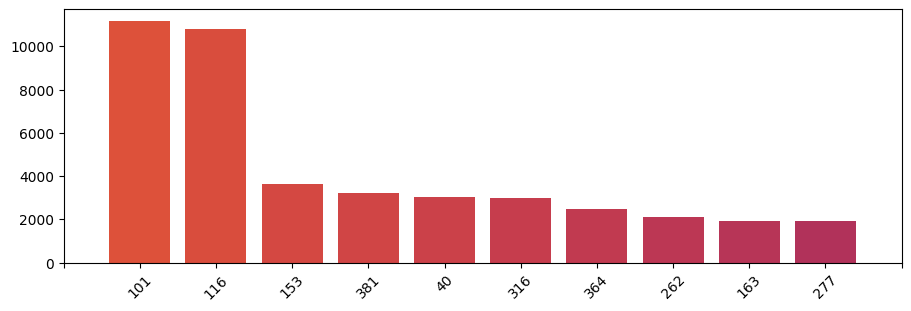

In [17]:
a = (df.groupby(['br'])['mortos'].sum()).sort_values(ascending=False)
plot_bar(a[:10])

- Como a proporção entre acidentes urbanos e rurais varia por região do Brasil?

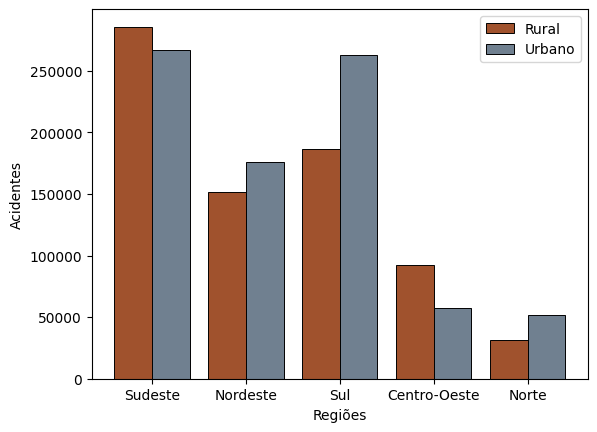

In [18]:
a = df.groupby(['regiao', 'uso_solo']).size()

r = list(df['regiao'].unique())

rrl = []
urb = []

for i in r:
    rrl.append(a[i]['Rural'])
    urb.append(a[i]['Urbano'])

l = len(r)

plt.bar(np.arange(len(r))-0.2, rrl, width=0.4, color='sienna',edgecolor='black', linewidth=0.7)
plt.bar(np.arange(len(r))+0.2, urb, width=0.4, color='slategrey', edgecolor='black', linewidth=0.7)

plt.xticks(np.arange(len(r)), labels=r)

plt.xlabel('Regiões')
plt.ylabel('Acidentes')

plt.legend(['Rural', 'Urbano'])

plt.show()


- Quais são as 10 causas mais frequentes de acidentes no Brasil?

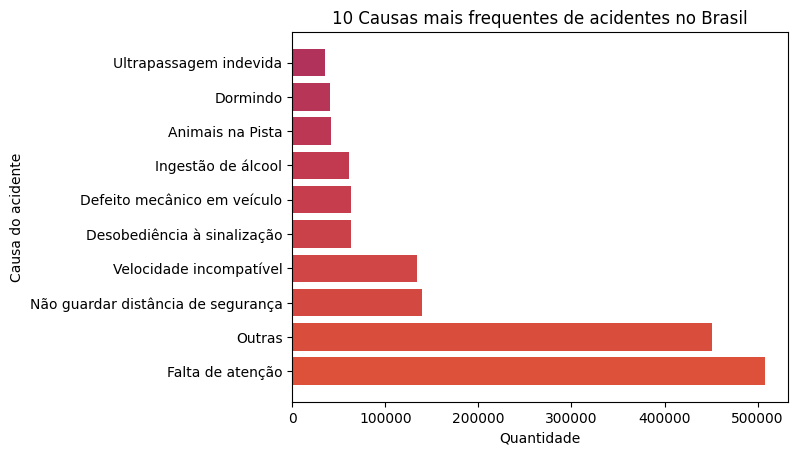

In [19]:
a = df.groupby(['causa_acidente'])['causa_acidente'].size().sort_values(ascending=False)[:10]

plt.barh(a.index, a.values, align='center', color=color1)
plt.ylabel('Causa do acidente')
plt.xlabel('Quantidade')
plt.title('10 Causas mais frequentes de acidentes no Brasil')
plt.show()

- A participação relativa de cada causa mudou ao longo dos anos?

Podemos observar que sim

In [20]:
n = df.groupby(['causa_acidente', 'ano']).size()
d = df.groupby(['causa_acidente']).size()
p = ((n/d)*100).round(2)
p.unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
causa_acidente,,,,,,,,,,
Animais na Pista,10.05,10.96,10.06,11.48,11.98,11.55,11.40,8.94,7.37,6.23
Defeito mecânico em veículo,8.59,9.31,9.57,11.04,11.10,10.86,11.38,10.94,9.10,8.12
Defeito na via,9.95,9.29,11.07,10.23,11.82,9.91,11.61,11.01,8.45,6.66
Desobediência à sinalização,6.35,7.21,8.12,11.24,12.28,12.23,12.69,12.82,9.44,7.62
Dormindo,8.22,8.14,8.15,10.76,10.77,11.31,11.80,11.72,9.94,9.20
Falta de atenção,8.32,9.13,10.26,12.00,12.52,12.06,12.39,10.86,7.25,5.21
Ingestão de álcool,5.05,5.80,7.83,11.08,12.30,12.36,12.25,12.03,10.98,10.31
Não guardar distância de segurança,5.81,6.96,8.20,11.14,12.37,13.43,15.41,13.99,8.15,4.54
Outras,10.19,11.07,12.31,12.60,12.52,10.99,9.76,8.64,6.44,5.47


- Acidentes em chuva são mais graves do que em tempo claro? Não!

In [21]:
n = df.groupby(['condicao_metereologica', 'classificacao_acidente']).size()
d = df.groupby(['condicao_metereologica']).size()
p = ((n/d)*100).round(2)
p.unstack(level=1, fill_value=0).loc[['Ceu Claro', 'Chuva']]

classificacao_acidente,Com Vítimas Fatais,Com Vítimas Feridas,Ignorado,Sem Vítimas
condicao_metereologica,,,,
Ceu Claro,4.59,39.19,0.80,55.43
Chuva,2.97,31.28,0.72,65.03


- A condição meteorológica influencia o tipo de acidente mais frequente? Sim!

In [22]:
n = df.groupby(['condicao_metereologica', 'tipo_acidente']).size()
d = df.groupby(['condicao_metereologica']).size()
p = ((n/d)*100).round(2)
p.unstack(level=0, fill_value=0)

condicao_metereologica,Ceu Claro,Chuva,Granizo,Ignorada,Neve,Nevoeiro/neblina,Nublado,Sol,Vento
tipo_acidente,,,,,,,,,
Atropelamento de animal,2.98,0.88,1.37,5.92,7.62,5.55,2.59,0.60,5.35
Atropelamento de pessoa,3.34,1.34,1.71,4.38,2.86,2.14,3.13,2.18,4.46
Capotamento,4.22,8.23,8.22,5.28,5.71,6.58,4.41,3.35,5.94
Colisão Transversal,10.90,5.84,4.79,8.30,6.67,7.54,10.28,12.41,8.69
Colisão com bicicleta,1.45,0.41,0.68,1.70,0.95,0.68,1.17,1.24,1.54
Colisão com objeto fixo,4.72,11.13,7.88,5.40,8.57,8.58,6.31,3.59,6.08
Colisão com objeto móvel,1.05,0.60,0.68,1.10,0.00,0.76,1.03,0.96,1.43
Colisão frontal,3.85,4.10,3.08,4.68,4.76,5.58,3.67,2.68,4.70
Colisão lateral,17.39,10.20,13.36,14.35,12.38,10.38,16.60,20.45,13.81


- Qual tipo de pista concentra mais acidentes fatais?


In [23]:
df.groupby(['tipo_pista', 'classificacao_acidente']).size().unstack(level=0).loc[['Com Vítimas Fatais']]

tipo_pista,Dupla,Múltipla,Simples
classificacao_acidente,,,
Com Vítimas Fatais,15843,2228,44776


- O traçado da via influencia a gravidade dos acidentes?

Podemos ver que sim

In [24]:
num = df.groupby(['tracado_via', 'classificacao_acidente']).size()
den = df.groupby('tracado_via').size()
res = ((num / den)*100).round(2)
res.unstack(level=0, fill_value=0)

tracado_via,Cruzamento,Curva,Reta
classificacao_acidente,,,
Com Vítimas Fatais,1.46,4.43,4.13
Com Vítimas Feridas,37.78,38.09,36.81
Ignorado,0.39,0.94,0.72
Sem Vítimas,60.37,56.54,58.33


- Existe um perfil de risco combinando tipo de pista, traçado e condição meteorológica?

Podemos ver que a reta é quem domina, independente da situação

In [25]:
num = df.groupby(['tracado_via', 'classificacao_acidente', 'condicao_metereologica']).size()
den = df.groupby(['condicao_metereologica', 'classificacao_acidente']).size()
res = ((num / den)*100).round(2)
res.unstack(level=0, fill_value=0)

tracado_via                                    Cruzamento  Curva    Reta
classificacao_acidente condicao_metereologica                           
Com Vítimas Fatais     Ceu Claro                     2.43  20.37   77.19
                       Chuva                         1.34  39.09   59.57
                       Granizo                       0.00  50.00   50.00
                       Ignorada                      1.46  19.51   79.03
                       Neve                          0.00   0.00  100.00
                       Nevoeiro/neblina              3.32  29.98   66.70
                       Nublado                       2.55  23.42   74.03
                       Sol                           3.34  24.41   72.24
                       Vento                         1.13  16.92   81.95
Com Vítimas Feridas    Ceu Claro                     6.77  18.06   75.17
                       Chuva                         3.76  40.25   55.99
                       Granizo                       0.00  30.23   69.77
                       Ignorada                      4.97  19.08   75.95
                       Neve                          2.56  25.64   71.79
                       Nevoeiro/neblina              5.50  33.21   61.29
                       Nublado                       7.41  21.93   70.66
                       Sol                           8.67  17.88   73.45
                       Vento                         5.97  16.37   77.66
Ignorado               Ceu Claro                     3.74  23.80   72.46
                       Chuva                         2.24  37.11   60.65
                       Granizo                       0.00   0.00  100.00
                       Ignorada                      3.61  27.84   68.56
                       Neve                          0.00   0.00  100.00
                       Nevoeiro/neblina              4.27  34.76   60.98
                       Nublado                       3.76  27.58   68.67
                       Sol                           3.09  25.25   71.67
                       Vento                         3.45  15.52   81.03
Sem Vítimas            Ceu Claro                     6.98  15.70   77.32
                       Chuva                         3.96  39.39   56.65
                       Granizo                       2.03  26.90   71.07
                       Ignorada                      5.05  17.88   77.07
                       Neve                          5.26  26.32   68.42
                       Nevoeiro/neblina              5.40  32.62   61.98
                       Nublado                       7.59  20.02   72.39
                       Sol                           9.39  13.88   76.74
                       Vento                         5.37  15.76   78.87

- O perfil de causas de acidentes mudou entre o início e o fim do período analisado?


In [26]:
df.groupby(['tipo_acidente', 'ano']).size().unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
tipo_acidente,,,,,,,,,,
Atropelamento de animal,3556,3868,3712,4250,4446,4287,4096,3174,2639,2178
Atropelamento de pessoa,3852,4464,4797,5299,5089,4687,4420,4150,3662,3520
Capotamento,6941,7240,7694,8576,8765,8415,7926,7424,6549,6776
Colisão Transversal,11817,13245,14900,17747,19445,18720,18873,17935,13139,10668
Colisão com bicicleta,2466,2406,2231,2280,2046,1714,1577,1346,1245,1235
Colisão com objeto fixo,8183,8732,10546,11215,11383,10628,10060,9153,7621,6678
Colisão com objeto móvel,1517,1604,1738,1960,1845,1731,1672,1372,912,564
Colisão frontal,4575,4741,5183,6234,6589,6473,6797,6873,5720,5250
Colisão lateral,20367,23676,25829,30675,33213,31753,32256,27944,17034,11215


- A letalidade dos acidentes melhorou ao longo do tempo em cada UF?

Podemos observar que sim, na maiora dos casos. Além disso, podemos observar o padrão seguindo a série temporal de acidentes ao longos dos anos que foi destacado anteriormente


In [27]:
df.groupby(['uf', 'ano'])['mortos'].sum().unstack(level=-1)

ano,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
uf,,,,,,,,,,
AC,20,13,31,14,23,21,23,32,20,23
AL,132,102,125,153,156,191,148,149,118,104
AM,12,11,11,18,34,19,18,18,15,22
AP,15,13,9,12,19,12,28,10,11,16
BA,605,660,638,812,779,849,799,794,642,610
CE,182,193,141,276,227,238,233,291,202,224
DF,67,49,43,41,63,71,40,46,47,58
ES,217,208,220,315,317,261,303,279,172,187
GO,325,391,451,515,510,519,504,468,442,351


- Existem picos atípicos de acidentes em datas específicas como feriados e carnaval?

Como podemos ver abaixo, temos um único comportamento atípico no final do ano, geralmente associados a data festivas como natal e ano novo, que normalmente há um consumo alto de álcool.

Apesar dos dados indicarem que não tem associação o álcool com as datas festivas, há um fato que o condutor pode recusar realizar o teste do bafômetro no momento da ocorrência, possibilitando um descarte dessa causa no momento da ocorrência.

Por fim, como para se pegar as datas festivas precisaríamos ir contando por ano as datas necessariamente, por haver mudanças, generalizei por mês.

In [28]:
df.groupby(['mes', 'causa_acidente']).size().unstack(level=0)

mes,1,2,3,4,5,6,7,8,9,10,11,12
causa_acidente,,,,,,,,,,,,
Animais na Pista,3221,3057,3412,3609,3896,3789,3929,3752,3478,3445,2975,3256
Defeito mecânico em veículo,5414,5139,5533,5223,5135,4741,5069,5059,5143,5336,5131,5994
Defeito na via,2363,2227,2437,2273,2135,1803,2058,1568,1467,1539,1617,2108
Desobediência à sinalização,5228,4683,5337,5352,5526,5304,5451,5257,5342,5487,4976,5738
Dormindo,3654,3306,3375,3094,3270,3238,3116,3124,3305,3573,3434,4420
Falta de atenção,42139,39151,41835,42648,43890,42311,43455,41811,41236,42018,40137,46753
Ingestão de álcool,4273,4332,5088,5042,5629,5329,5274,5242,5173,5160,5025,5856
Não guardar distância de segurança,12804,11221,11673,12315,11828,11266,11657,10982,10840,10785,10970,13633
Outras,38584,34572,38344,36982,37798,36247,37556,35522,36230,38748,37556,43037


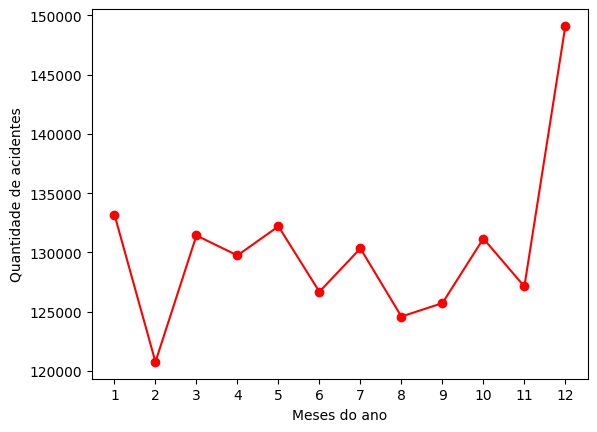

In [29]:
a = df.groupby(['mes']).size()

fig = plt.figure()

ax = fig.add_subplot()

ax.plot(a.index, a.values, '-ro')

plt.xlabel('Meses do ano')
plt.ylabel('Quantidade de acidentes')

ax.set(xticks=np.arange(1, len((a.index))+1))

plt.show()

- Quais UFs apresentam comportamento atípico em relação à média nacional de fatalidade?

MA, TO e RR representam os mais atípicos, curiosamente estados mais ao norte do país

In [30]:
df['mortos'].mean().round(2)

np.float64(0.05)

In [31]:
(df.groupby(['uf'])['mortos'].mean()).round(2).sort_values(ascending=False)


uf
MA    0.12
TO    0.11
RR    0.10
AM    0.09
PI    0.08
BA    0.08
AL    0.08
MT    0.07
CE    0.07
AP    0.07
PE    0.07
SE    0.07
GO    0.06
MS    0.06
AC    0.05
PA    0.05
RN    0.05
MG    0.05
PB    0.05
ES    0.04
DF    0.04
RJ    0.04
PR    0.04
RO    0.04
RS    0.03
SC    0.03
SP    0.03
Name: mortos, dtype: float64